<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
General Comparison of Clustering Algorithms
</h1>


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from kneed import KneeLocator

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.decomposition import PCA
import plotly.express as px

import warnings
warnings.simplefilter(action='ignore')

In [68]:
# Function to calculate Dunn Index
from scipy.spatial.distance import cdist

def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute intra-cluster distances (max pairwise distance within each cluster)
    intra_distances = []
    for cluster in unique_clusters:
        points_in_cluster = X[labels == cluster]
        if len(points_in_cluster) > 1:
            intra_distances.append(np.max(cdist(points_in_cluster, points_in_cluster)))  # Max distance within cluster

    # Compute inter-cluster distances (min distance between cluster centroids)
    cluster_centers = np.array([X[labels == cluster].mean(axis=0) for cluster in unique_clusters])
    inter_distances = cdist(cluster_centers, cluster_centers)
    np.fill_diagonal(inter_distances, np.inf)  # Ignore self-distances
    min_inter_distance = np.min(inter_distances)  # Min distance between any two clusters

    return min_inter_distance / max(intra_distances)

In this stage, we define a set of general exploratory questions to investigate potential patterns within the movie dataset — such as identifying groups based on commercial success, audience ratings, or structural characteristics.

For each question, we:

- Select relevant features from the dataset.
- Apply **all three clustering algorithms** (KMeans, DBSCAN, Agglomerative) on the same subset.
- Analyze and compare the clustering results across methods.

📌 **Important:**  
The questions are **not tailored to any specific algorithm**. Instead, we use them to evaluate which algorithm performs better in revealing meaningful, distinct clusters for each type of analysis.

This approach helps us assess:
- How consistently each algorithm groups the data.
- Which method produces clusters that are more interpretable.
- The overall strengths and limitations of each technique in real-world applications.


In [69]:
data = pd.read_csv('tmdb_movies_cleaned.csv')

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

### 🧹 Removing Irrelevant or Non-Numeric Features

To reduce dimensionality and help with picking the relevent questions to explore, we removed several features that are not suitable for distance-based analysis:

- `id`, `title`: Identifiers or free text with no numerical meaning.
- `release_date`: Replaced with `release_year`, which is easier to compare.
- `top10_prod_comps`, `main_production_country` and `season`: Text-based categorical fields that would require encoding and may distort distances.
- `changed_title`: Technical field that does not describe the movie's content.
- `is_english_spoken`, `has_tagline`, `belongs_to_collection`, `has_homepage` and Genres: Too many boolean features will make clustering complex.

This step ensures that the clustering process is focused on interpretable and comparable features only.

In [71]:
data_clean = data.copy()

columns_to_drop = [
    'id',
    'title',
    'release_date',
    'top10_prod_comps',
    'main_production_country',
    'season',
    'changed_title',
    'has_tagline',
    'belongs_to_collection',
    'has_homepage'
]

data_clean = data_clean.drop(columns=columns_to_drop)

In [72]:
data_clean = data_clean.select_dtypes(include=['int64', 'float64'])

## 🧠 Data Preprocessing Summary Before Clustering

To ensure a fair, meaningful, and effective comparison between clustering algorithms, the dataset is being preprocessed through the following steps:

### 1. 🔁 Log Transformation of Skewed Features
Many features in real-world datasets exhibit **right-skewed distributions**. To address this:
- A **log transformation** is applied to reduce skewness
- It compresses high-value ranges and expands low-value ranges, improving feature symmetry

* *Why this is fare*: If the original scale hurts one algorithm more than others, that's a bias in the data, not a feature of the algorithm.  
  
This step is essential for **distance-based clustering**, as it prevents skewed features from dominating distance calculations and helps reveal the true structure of clusters.

### 2. 📏 Feature Normalization (StandardScaler)
After transformation, features are standardized to have:
- Mean = 0  
- Standard deviation = 1

This step ensures that **all features contribute equally** to the distance metrics used in clustering. Without normalization, features with larger numerical ranges could disproportionately influence the outcome, biasing the clustering process.

---

- These preprocessing steps align the data with the assumptions and sensitivities of most clustering algorithms, providing a consistent and fair foundation for comparison.
- We will **not be removing outliers** because that can cause bias for certain clustering algorithms that are more sensitive to noise.


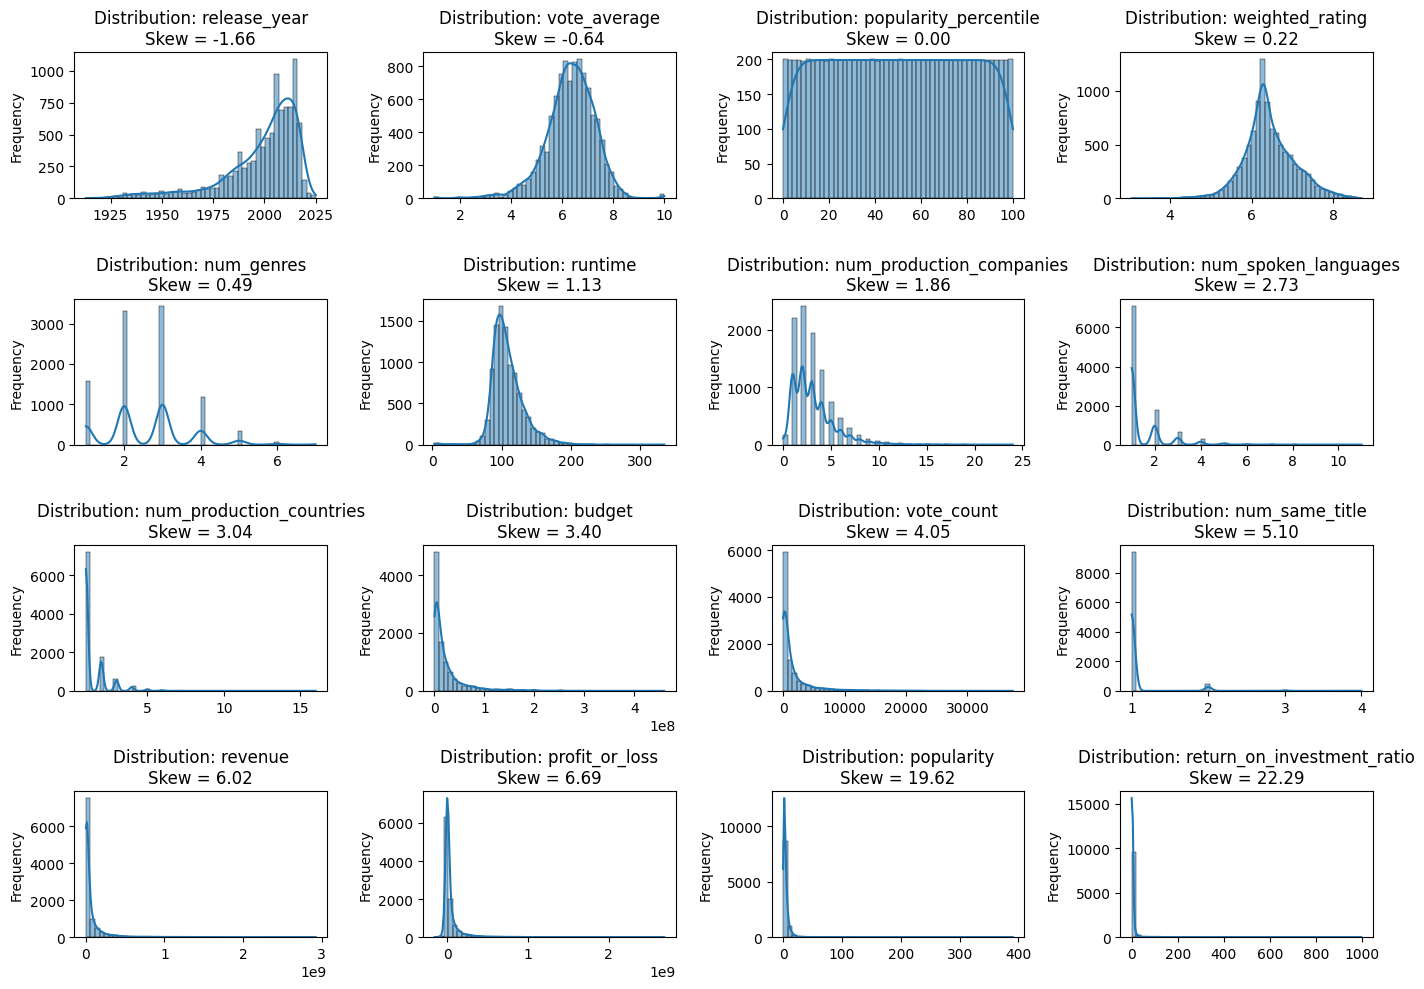

In [73]:
feature_skewness = data_clean.skew().sort_values(ascending=True)

plt.figure(figsize=(14, 10))
for i, feature in enumerate(feature_skewness.index[:16]):
    plt.subplot(4, 4, i+1)
    sns.histplot(data_clean[feature], bins=50, kde=True)
    plt.title(f'Distribution: {feature}\nSkew = {feature_skewness[feature]:.2f}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [74]:
# log transformation for skewed features: (skewness > 1.85)
skewed_cols = feature_skewness[feature_skewness > 1.85].index

data_clean[skewed_cols] = np.log1p(data_clean[skewed_cols])

In [75]:
scaler = StandardScaler()
scaled_clean_data = scaler.fit_transform(data_clean)

In [76]:
data_clean.dtypes

runtime                         int64
budget                        float64
revenue                       float64
popularity                    float64
vote_average                  float64
vote_count                    float64
num_same_title                float64
num_genres                      int64
num_production_companies      float64
num_production_countries      float64
num_spoken_languages          float64
popularity_percentile         float64
weighted_rating               float64
release_year                    int64
return_on_investment_ratio    float64
profit_or_loss                float64
dtype: object

## ⚙️ Question Ensembling

With our cleaned and preprocessed dataset, we aim to formulate a set of guiding questions that will allow us to **compare the performance and behavior of different clustering algorithms**. These questions are designed to reveal **distinct patterns and insights** that may emerge depending on the algorithm applied.

Beyond algorithmic comparison, we also want these questions to uncover **practical insights** that can inform future decisions or analyses.

### 🎯 Our Three Guiding Questions:

1. **Commercial Success Patterns**  
   → Can we identify groupings of movies based on financial success (e.g., budget, revenue, profitability)?

2. **Structural Attribute Patterns**  
   → Do common traits or structural characteristics (e.g., runtime, release year) define each cluster?

3. **Public Critique Patterns**  
   → How do clusters differ in terms of audience reception, ratings or critical acclaim?

---

## 🧩 Question 1: Commercial Success Patterns

**❓ Question:**  
Can we identify groupings of movies based on financial success?

**🎯 Goal:**  
Use clustering algorithms to discover natural groupings of movies based on financial metrics (budget and revenue),  
and interpret whether these groupings reveal insights about commercial performance.

#### Feature Selection – Financial Performance Indicators:


| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `budget`                  | 	The production cost of the movie – a proxy for investment. |
| `revenue`             | 	The total box office income – a proxy for public demand and commercial success. |

In [77]:
selected_features = [
    'budget',
    'revenue'
]

X = data_clean[selected_features].copy()

## **K-Means Clustering:**

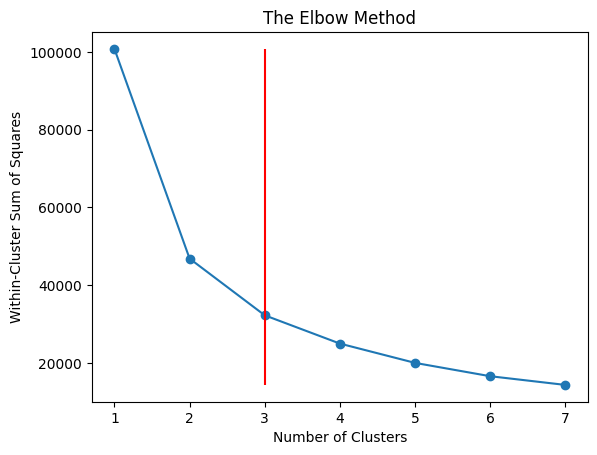

In [78]:
# checking the elbow method to determine the best number of K's for clustering
wcss = []
for i in range(1,8):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42).fit(X)
    wcss.append(kmeans.inertia_)

k_elbow = KneeLocator(x = range(1,8),y=wcss,curve='convex',direction='decreasing').elbow
plt.plot(range(1,8),wcss,marker='o')
plt.vlines(k_elbow,np.min(wcss),np.max(wcss),color='red')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares");

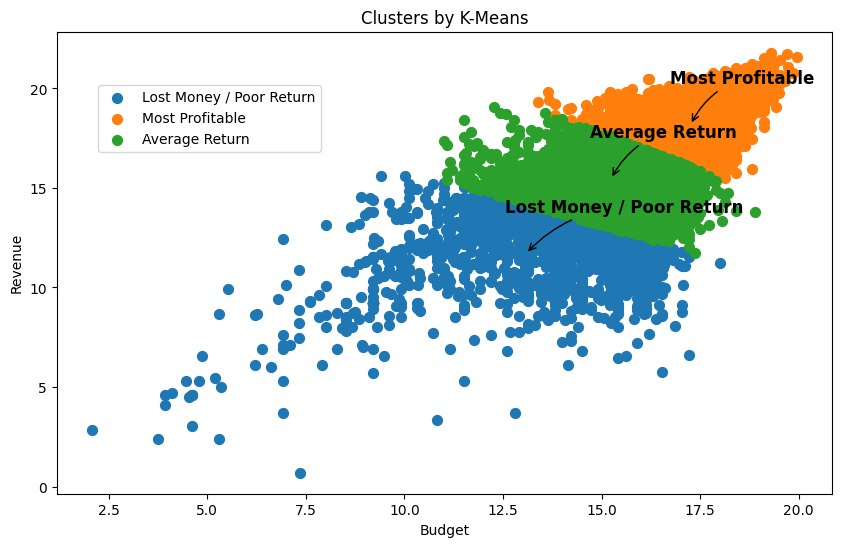

K-Means Clustering Metrics:
Silhouette Score: 0.4092
Davies-Bouldin Score: 0.8783
Dunn Index: 0.1880
Calinski-Harabasz Score: 10551.4707


In [79]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_raw = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# Map the labels: cluster with higher average budget → "Solo/Budget Travelers"
cluster_order = centers[:, 0].argsort()  # sort by 'Budget'
label_map = {}
label_map[cluster_order[0]] = "Lost Money / Poor Return"
label_map[cluster_order[1]] = 'Average Return'
label_map[cluster_order[2]] = 'Most Profitable'

# Convert X to array
X_array = X.values

# Plot
plt.figure(figsize=(10, 6))
for cluster in np.unique(labels_raw):
    plt.scatter(X_array[labels_raw == cluster, 0], X_array[labels_raw == cluster, 1],
                s=50,
                label=label_map[cluster],
                zorder=3)

# Annotate centers
for cluster in np.unique(labels_raw):
    label = label_map[cluster]
    x, y = centers[cluster]
    plt.annotate(label, xy=(x, y), xytext=(-15, 40),
                 va='top', fontsize=12, fontweight='bold',
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle='arc3,rad=0.2'))

plt.title('Clusters by K-Means')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=[0.35, 0.9])
plt.show()

# Clustering metrics
sil_score = silhouette_score(X, labels_raw)
db_score = davies_bouldin_score(X, labels_raw)
cal_score = calinski_harabasz_score(X, labels_raw)
dunn_score = dunn_index(X, labels_raw)

print(f"K-Means Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

## **Hierarchial Clustering:**

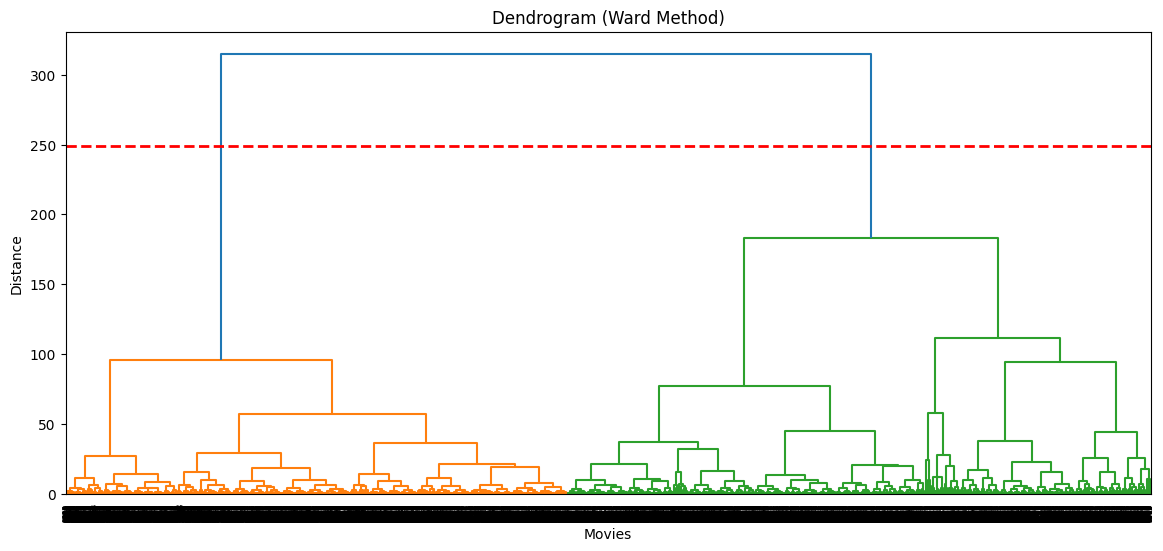

In [80]:
# Hierarchical Clustering: (we will use the Ward method for linkage becuase it is more common and fits well with most datasets)
linkage_matrix = linkage(X, method='ward')

merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

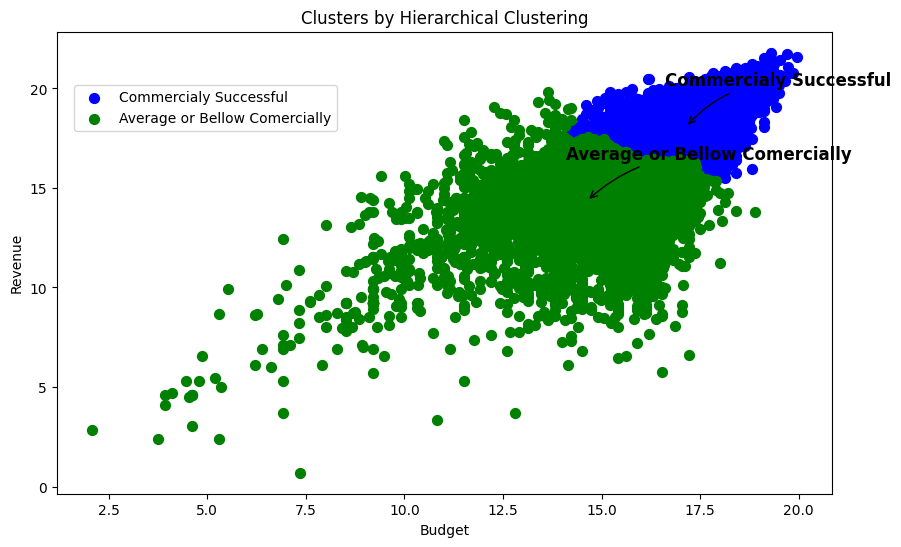

Hierarchical Clustering Metrics:
Silhouette Score: 0.4261
Davies-Bouldin Score: 0.7928
Dunn Index: 0.2180
Calinski-Harabasz Score: 9656.2043


In [81]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

# Scatter plot for hierarchical clusters
plt.figure(figsize=(10,6))
labels = ['Commercialy Successful', 'Average or Bellow Comercially']

# Convert DataFrame to numpy array for indexing
X_array = X.values

# Plot clusters
plt.scatter(X_array[hier_labels == 1, 0], X_array[hier_labels == 1, 1], 
            s=50, c='blue', label=labels[0], zorder=3)
plt.scatter(X_array[hier_labels == 2, 0], X_array[hier_labels == 2, 1], 
            s=50, c='green', label=labels[1], zorder=3)

# Compute cluster centers
centers = X.groupby(hier_labels).mean().values

# Plot annotations
for label, x, y in zip(labels, centers[:, 0], centers[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-15, 40),
                 va='top', fontsize=12, fontweight='bold', 
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle='arc3,rad=0.2'))

plt.title('Clusters by Hierarchical Clustering')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=[0.37, 0.9])
plt.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

## **DBSCAN Clustering:**

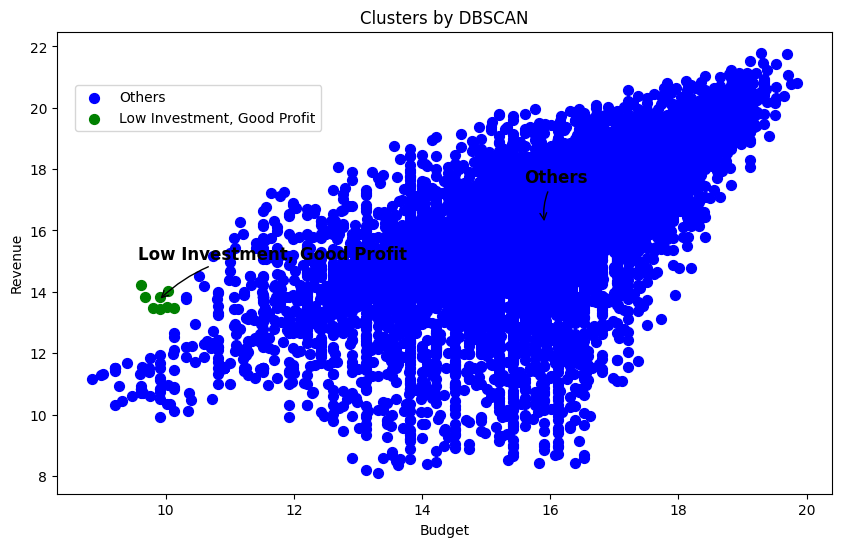

DBSCAN Clustering Metrics:
Silhouette Score: 0.4210
Davies-Bouldin Score: 0.3720
Dunn Index: 0.1474
Calinski-Harabasz Score: 150.3584


In [82]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)

# Filter out noise points (label -1)
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# Prepare cluster labels manually based on visual inspection
labels = ['Others', 'Low Investment, Good Profit']  # Update as needed

# Convert to numpy for indexing
X_core_array = X_core.values

# Plot DBSCAN clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_core_array[labels_core == 0, 0], X_core_array[labels_core == 0, 1],
            s=50, c='blue', label=labels[0], zorder=3)
plt.scatter(X_core_array[labels_core == 1, 0], X_core_array[labels_core == 1, 1],
            s=50, c='green', label=labels[1], zorder=3)

# Compute cluster centers
centers = X_core.groupby(labels_core).mean().values

# Annotate clusters
for label, x, y in zip(labels, centers[:, 0], centers[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-15, 40),
                 va='top', fontsize=12, fontweight='bold', 
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle='arc3,rad=0.2'))

plt.title('Clusters by DBSCAN')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=[0.35, 0.9])
plt.show()

sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)
print(f"DBSCAN Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")



### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| Best Value ✅             |      1            |         0           |    ∞        |        ∞                |
| Worst Value ❌            |      -1            |         ∞          |    0        |        0                |
| KMeans                    |         0.409    |        0.878         |     0.188    |     **10,551.4707**          |
| Hierarchical              |      **0.426**        |         0.792        |    **0.218**   |        9656.2043        |
| DBSCAN                    |      0.421      |         **0.372**        |    0.147   |        150.358           |


___
## 🧩 Question 2: Structural Attribute Patterns

**❓ Question:**  
Are there structural groupings among the movies — based on features such as runtime, release year or number of genres — that do not necessarily relate to quality or commercial success?

**🎯 Goal:**  
To explore whether movies can be clustered according to **structural attributes** rather than content or performance. These attributes may reveal latent patterns in how movies are produced or categorized over time.

This question is particularly useful for testing whether clustering algorithms can uncover **hidden structural trends** in the dataset that aren't explicitly tied to audience reception or box office revenue.

#### Feature Selection – Structural Movie Characteristics:

| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `runtime`                  | Indicates the length of the movie – may help identify clusters of short vs. long films. |
| `release_year`             | Reflects the era of release. Movies from similar periods may share production trends or stylistic patterns. |
| `budget`                   | Budget size represents the scale of production – high-budget vs. low-budget films may form distinct groups. |
| `num_genres`               | A movie with multiple genres may differ in structure or marketing from single-genre films. |
| `num_production_companies` | A high number may indicate complex or large-scale productions; low values may imply indie films. |
| `num_production_countries` | International co-productions may share characteristics distinct from single-country productions. |
| `num_spoken_languages`     | Multi-language films may target global audiences and differ structurally from single-language films. |

In [83]:
selected_features = [
    'runtime',
    'release_year',
    'budget',
    'num_genres',
    'num_production_companies',
    'num_production_countries',
    'num_spoken_languages'
]

X = data_clean[selected_features].copy()

In [84]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

In [85]:
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (2D): {total_var:.2%}")

Total variance explained (2D): 99.46%


## **K-Means Clustering:**

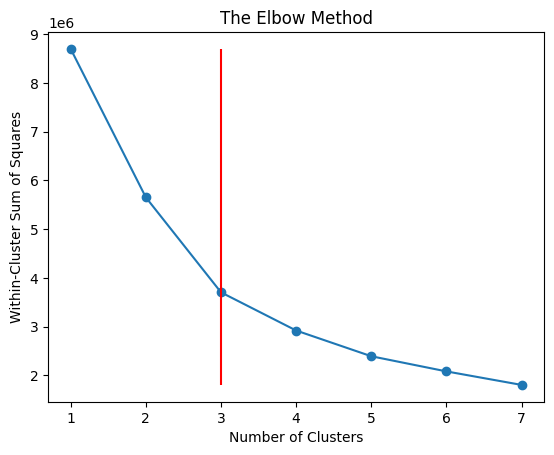

In [86]:
# checking the elbow method to determine the best number of K's for clustering
wcss = []
for i in range(1,8):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42).fit(X)
    wcss.append(kmeans.inertia_)

k_elbow = KneeLocator(x = range(1,8),y=wcss,curve='convex',direction='decreasing').elbow
plt.plot(range(1,8),wcss,marker='o')
plt.vlines(k_elbow,np.min(wcss),np.max(wcss),color='red')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares");

In [87]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# Add results to data_clean DataFrame
data_clean['cluster_kmeans'] = labels_kmeans.astype(str)

# Perform PCA (if not already done)
from sklearn.decomposition import PCA
pca_result = PCA(n_components=2).fit_transform(X)
data_clean['pca_1'] = pca_result[:, 0]
data_clean['pca_2'] = pca_result[:, 1]

# Plot PCA clusters with Plotly
import plotly.express as px

fig = px.scatter(
    data_clean,
    x='pca_1',
    y='pca_2',
    color='cluster_kmeans',
    title="2D PCA – K-Means Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

# Clustering metrics
sil_score = silhouette_score(X, labels_kmeans)
db_score = davies_bouldin_score(X, labels_kmeans)
cal_score = calinski_harabasz_score(X, labels_kmeans)
dunn_score = dunn_index(X, labels_kmeans)

print(f"K-Means Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

K-Means Clustering Metrics:
Silhouette Score: 0.4437
Davies-Bouldin Score: 0.8274
Dunn Index: 0.1879
Calinski-Harabasz Score: 6705.6979


## **Hierarchial Clustering:**

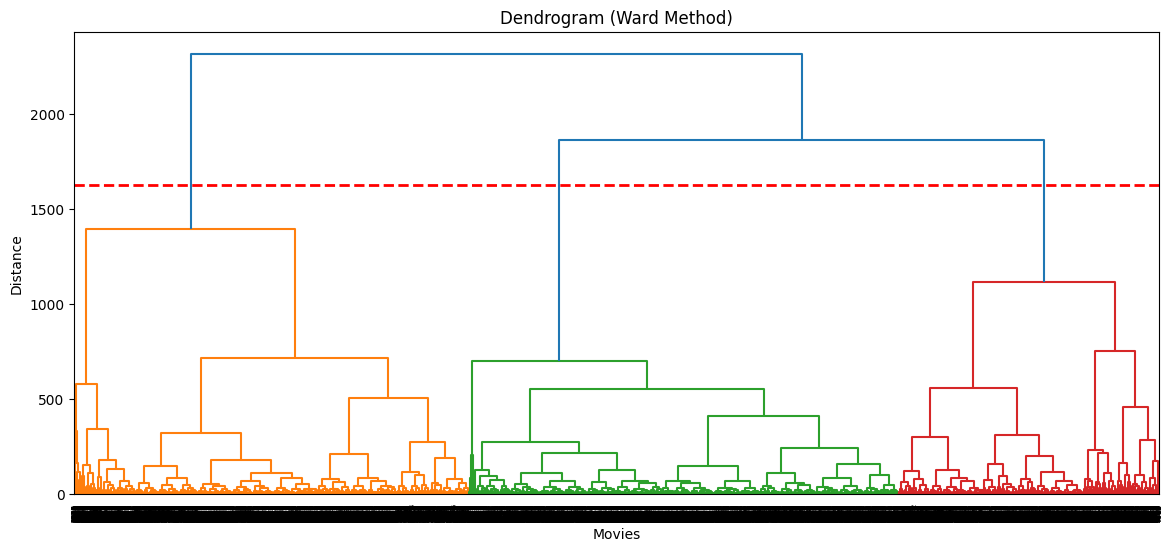

In [88]:
# Hierarchical Clustering:
linkage_matrix = linkage(X, method='ward')

# cutting the dendrogram to find the optimal number of clusters - we will use the maximum gap method
merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [89]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

data_clean['cluster_hierarchical'] = hier_labels.astype(str)

data_clean['pca_1'] = pca_result[:, 0]
data_clean['pca_2'] = pca_result[:, 1]

fig = px.scatter(
    data_clean,
    x='pca_1',
    y='pca_2',
    color='cluster_hierarchical',
    title="2D PCA – Hierarchical Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")


Hierarchical Clustering Metrics:
Silhouette Score: 0.3317
Davies-Bouldin Score: 0.9630
Dunn Index: 0.1464
Calinski-Harabasz Score: 5144.6364


## **DBSCAN Clustering:**

In [90]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_result)

data_clean['cluster_dbscan'] = dbscan_labels.astype(str)
data_clean['pca_1'] = pca_result[:, 0]
data_clean['pca_2'] = pca_result[:, 1]

# Plot
fig = px.scatter(
    data_clean,
    x='pca_1',
    y='pca_2',
    color='cluster_dbscan',
    title="2D PCA – DBSCAN Clustering",
    opacity=0.7
)
fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

# === Filter out noise points ===
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# === Clustering Metrics (Core Points Only) ===
sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)

print(f"DBSCAN Clustering Metrics (Core Points Only):\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

DBSCAN Clustering Metrics (Core Points Only):
Silhouette Score: 0.0806
Davies-Bouldin Score: 2.6455
Dunn Index: 0.0607
Calinski-Harabasz Score: 166.5205




### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| Best Value ✅                |      1            |         0             |    ∞        |        ∞                |
| Worst Value ❌                |      -1            |         ∞             |    0        |        0                |
| KMeans                    |        **0.443**      |         **0.827**         |    **0.188**    |        **6705.6979**        |
| Hierarchical              |      0.331        |         0.963        |    0.146   |        5144.6364        |
| DBSCAN                    |      0.080      |         2.645        |    0.060   |        166.5205           |


___
## 🧩 Question 3: Public Critique Patterns

**❓ Question:**  
Is There a Natural Clustering of Movies Based on Critical/Audience Reception?

**🎯 Goal:**  
The goal is to determine whether a natural clustering of movies exists based on how they were received by audiences and critics and  
to examine whether movies can be grouped based on different levels of *perceived quality*, as reflected in quantitative data.

#### Feature Selection – Public Reception Metrics:

| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `vote_average`                  | Captures the average rating given by users – a direct indicator of audience-perceived quality. |
| `popularity`             | Reflects general public interest, combining views, searches, and engagement – often correlated with cultural relevance. |
| `vote_count`                   | 	Indicates the volume of audience participation – movies with high vote counts tend to have broader exposure or impact. |

In [91]:
selected_features = [
    'vote_average',
    'popularity',
    'vote_count',
]

X = data_clean[selected_features].copy()

## **K-Means Clustering:**

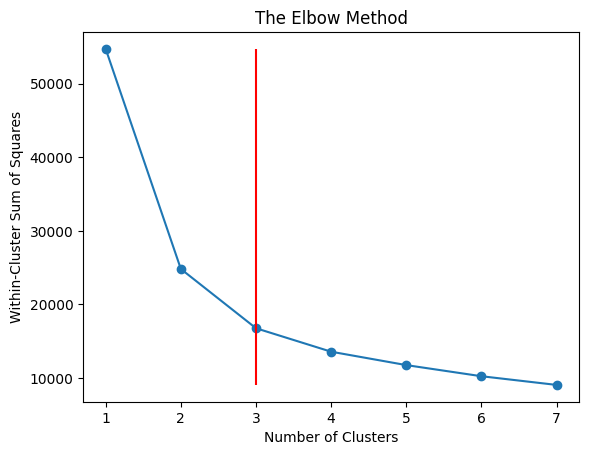

In [92]:
# checking the elbow method to determine the best number of K's for clustering
wcss = []
for i in range(1,8):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42).fit(X)
    wcss.append(kmeans.inertia_)

k_elbow = KneeLocator(x = range(1,8),y=wcss,curve='convex',direction='decreasing').elbow
plt.plot(range(1,8),wcss,marker='o')
plt.vlines(k_elbow,np.min(wcss),np.max(wcss),color='red')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares");

In [93]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X)  # X is the scaled data used for clustering

# Add cluster labels to original DataFrame
data_clean['cluster_kmeans'] = labels_kmeans.astype(str)

fig = px.scatter_3d(
    data_clean,
    x='vote_average',
    y='vote_count',
    z='popularity',
    color='cluster_kmeans',
    title='3D K-Means Clustering',
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

sil_score = silhouette_score(X, labels_kmeans)
db_score = davies_bouldin_score(X, labels_kmeans)
dunn_score = dunn_index(X, labels_kmeans)
cal_score = calinski_harabasz_score(X, labels_kmeans)

print(f"K-Means Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

K-Means Clustering Metrics:
Silhouette Score: 0.3780
Davies-Bouldin Score: 0.8722
Dunn Index: 0.2681
Calinski-Harabasz Score: 11248.1051


## **Hierarchial Clustering:**

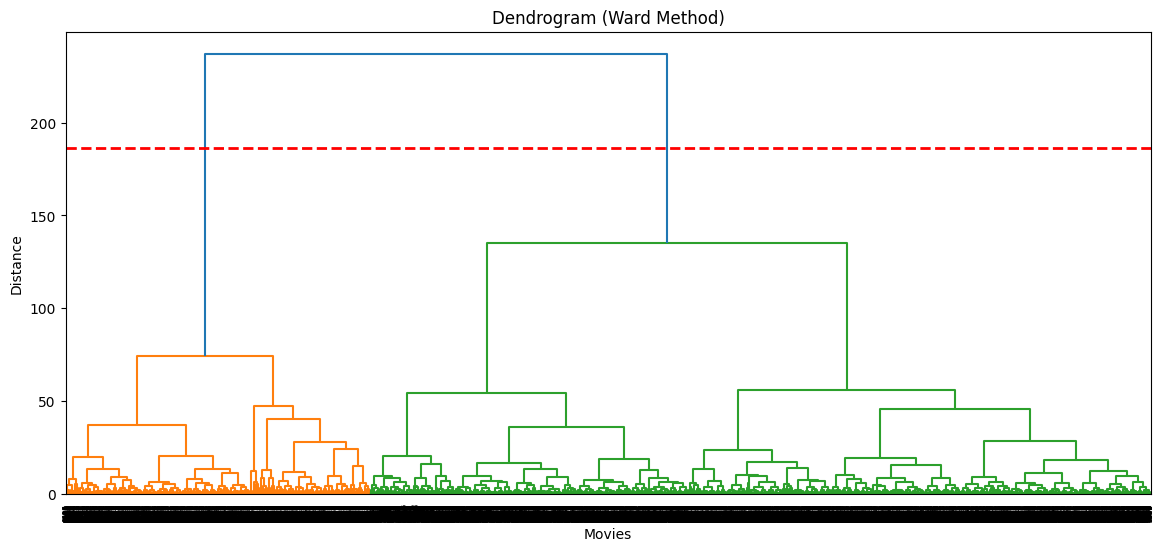

In [94]:
# Hierarchical Clustering:
linkage_matrix = linkage(X, method='ward')

merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [95]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

data_clean['cluster_hierarchical'] = hier_labels.astype(str)

fig = px.scatter_3d(
    data_clean,
    x='vote_average',
    y='vote_count',
    z='popularity',
    color='cluster_hierarchical',
    title='3D Hierarchical Clustering',
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")


Hierarchical Clustering Metrics:
Silhouette Score: 0.4587
Davies-Bouldin Score: 0.7792
Dunn Index: 0.4068
Calinski-Harabasz Score: 10527.9892


## **DBSCAN Clustering:**

In [96]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)

data_clean['cluster_dbscan'] = dbscan_labels.astype(str)

fig = px.scatter_3d(
    data_clean,
    x='vote_average',
    y='vote_count',
    z='popularity',
    color='cluster_dbscan',
    title='3D DBSCAN Clustering',
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

# === Filter out outliers ===
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# === Clustering Metrics (Core Points Only) ===
sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)

print(f"DBSCAN Clustering Metrics (Core Points Only):\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

DBSCAN Clustering Metrics (Core Points Only):
Silhouette Score: 0.5446
Davies-Bouldin Score: 0.3102
Dunn Index: 0.5462
Calinski-Harabasz Score: 174.1517


### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| Best Value ✅                |      1            |         0             |    ∞        |        ∞                |
| Worst Value ❌                |      -1            |         ∞             |    0        |        0                |
| KMeans                    |       0.378       |       0.872           |   0.268     |        **11,248.1051**       |
| Hierarchical              |      0.458        |         0.779        |    0.406   |        10,527.9892        |
| DBSCAN                    |      **0.544**      |         **0.310**        |    **0.546**   |        174.1517           |

---

## 📚 Final Summary & Conclusion

After a thorough and structured exploration of movie clustering using three unsupervised learning algorithms—**K-Means**, **Agglomerative Hierarchical Clustering**, and **DBSCAN**—our analysis addressed three key questions around **commercial success**, **structural patterns**, and **public reception**.

---

### 🔍 Summary of Methodology

**1. Data Cleaning & Preprocessing:**
- Removed irrelevant or highly sparse features that could distort distance metrics.
- Applied **log transformation** to mitigate skewness in financial/popularity data.
- Standardized features using **StandardScaler** to ensure fair feature contribution.

**2. Clustering Evaluation Criteria:**
- We used four metrics to evaluate clustering quality:
  - **Silhouette Score**: How well-separated the clusters are.
  - **Davies-Bouldin Score**: Cluster compactness vs. separation (lower is better).
  - **Dunn Index**: Measures cluster density separation (higher is better).
  - **Calinski-Harabasz Score**: Variance ratio between clusters (higher is better).

---

### 🧠 Insights by Question

#### 1. **Commercial Success Patterns**
- **Hierarchical Clustering** yielded the most balanced performance in Silhouette and Dunn scores, suggesting coherent commercial-based groups.
- **K-Means** showed strong variance separation (high Calinski-Harabasz), implying clear centroids around budget/revenue combinations.
- **DBSCAN** identified dense pockets but struggled with overall variance and coverage.

✅ **Takeaway**: Financial features formed interpretable clusters, indicating the presence of tiers in production scale and return on investment.

---

#### 2. **Structural Attribute Patterns**
- **K-Means** outperformed other models across all metrics, showing it captured structural trends effectively (runtime, number of genres, etc.).
- **Hierarchical Clustering** was a close second but formed less distinct groups.
- **DBSCAN** performed poorly due to the continuous nature and lack of dense local groupings in the feature space.

✅ **Takeaway**: Structural movie traits cluster well under centroid-based assumptions—movies appear to follow patterns in production design and format.

---

#### 3. **Public Critique Patterns**
- **DBSCAN** excelled here, identifying high-density regions of audience consensus—especially valuable for detecting niche fan-favorite clusters.
- **Hierarchical Clustering** offered good cohesion and a strong Dunn Index.
- **K-Means** again performed well in terms of variance but was less suited for modeling smaller, dense clusters of rating popularity.

✅ **Takeaway**: Public reception patterns are nuanced; DBSCAN’s flexibility helps uncover clusters of similarly-received movies that may not align with budget or structure.

---

### 🏁 Overall Conclusions

- **There is no universal best algorithm**—performance varies depending on the data domain:
  - **K-Means** excels in structured, evenly distributed feature spaces.
  - **Hierarchical Clustering** is powerful for revealing layered groupings and relationships.
  - **DBSCAN** shines in finding irregular, tightly packed clusters and handling noise.

- Our preprocessing pipeline, careful feature selection, and domain-focused question design allowed us to fairly evaluate each method’s strengths.

- Clustering provides valuable insight into movie landscapes—**from production trends to audience sentiment**—without requiring labeled data.

---

### 💡 Final Thought

This notebook illustrates that unsupervised learning, when paired with domain knowledge and the right questions, can uncover deep, actionable insights—even in noisy, complex datasets like movies.  
By aligning algorithm choice with the nature of the features and the business question, we gain not just clusters, but **meaningful stories** from the data.